--- ЗАДАНИЕ №2 ---
Входные параметры: lambda=0.2, mu=0.1, n=2, T=1000
Число поступивших заявок: 195 vs данные 5 работы: 182
Число обработанных заявок: 123 vs данные 5 работы: 113
Число отказов: 72 vs данные 5 работы: 69
Вероятность обработки (Q): 0.6308 vs данные 5 работы: 0.6209
Вероятность отказа (Pf): 0.3692 vs данные 5 работы: 0.3791
Суммарное время простоя каналов: 851.29 сек vs данные 5 работы: 815.6600
Вероятность загрузки каналов: 0.5744 vs данные 5 работы: 0.5921
--- ЗАДАНИЕ №3 ---
n     | lambda   | Qn (Обработка)  | Tn (Загрузка)  
--------------------------------------------------
2     | 0.2      | 0.5844          | 0.5713         
3     | 0.3      | 0.6503          | 0.6560         
4     | 0.4      | 0.6768          | 0.6940         
5     | 0.5      | 0.7312          | 0.7018         
6     | 0.6      | 0.7457          | 0.7298         
7     | 0.7      | 0.7587          | 0.7556         
8     | 0.8      | 0.7664          | 0.7624         
9     | 0.9      | 0.7647    

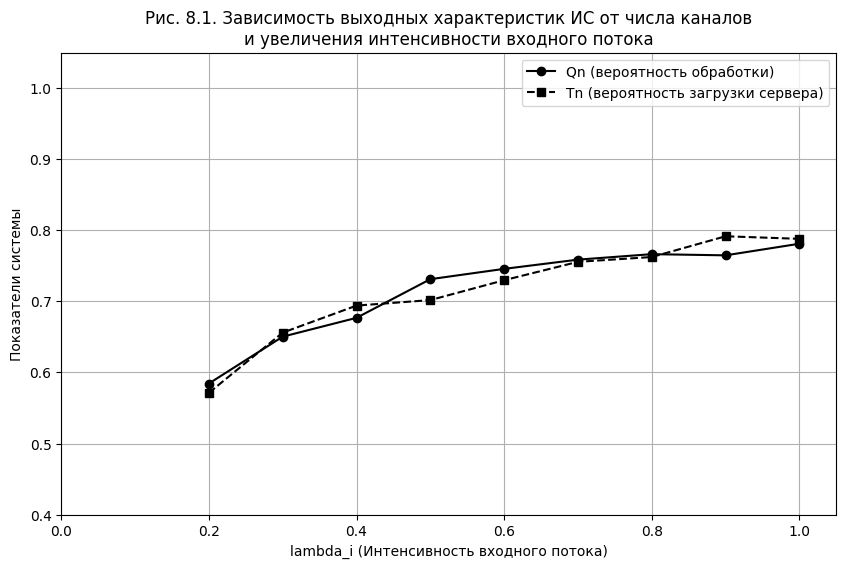

Вывод по заданию 3: Пропорциональное увеличение числа каналов компенсирует рост нагрузки и даже увеличивает общую эффективность системы (вероятность обработки растет).

--- ЗАДАНИЕ №4 ---
n     | lambda   | mu       | Q1 (Обработка)  | T1 (Загрузка)  
------------------------------------------------------------
1     | 0.1      | 0.1      | 0.5044          | 0.5134         
1     | 0.2      | 0.2      | 0.4831          | 0.5081         
1     | 0.3      | 0.3      | 0.4879          | 0.5068         
1     | 0.4      | 0.4      | 0.4926          | 0.4946         
1     | 0.5      | 0.5      | 0.5011          | 0.4961         
1     | 0.6      | 0.6      | 0.5007          | 0.5049         
1     | 0.7      | 0.7      | 0.4964          | 0.4922         
1     | 0.8      | 0.8      | 0.5093          | 0.4947         
1     | 0.9      | 0.9      | 0.4906          | 0.4983         
1     | 1.0      | 1.0      | 0.5078          | 0.4920         

* График для Задания 4 откроется в отдельном о

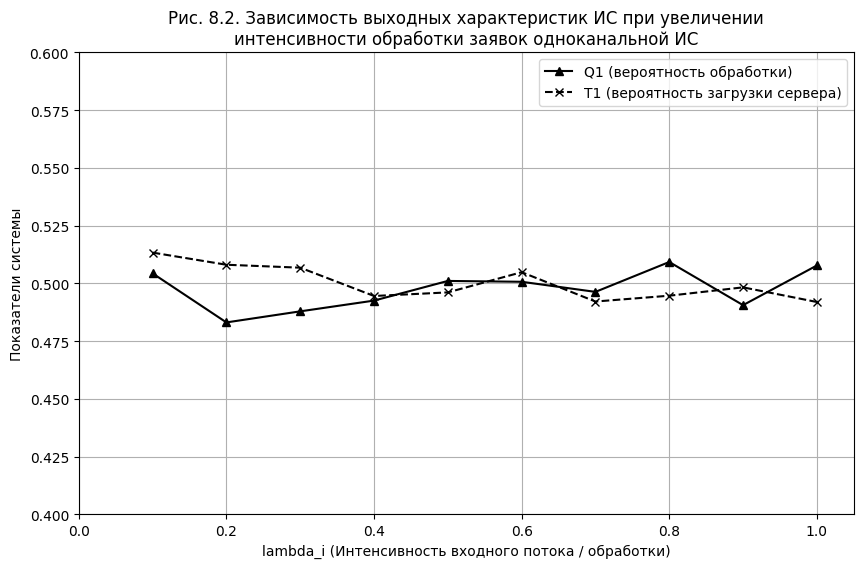

Вывод по заданию 4: Как видно из результатов, при пропорциональном увеличении потока и скорости одного канала, значения стремятся к 0.5. Архитектурное решение из Задания 3 (увеличение числа каналов) является более эффективным.



In [5]:
import random
import matplotlib.pyplot as plt

# ==========================================
# ЗАДАНИЕ №1: Разработка компьютерной программы
# ==========================================
def simulate_system(lam, mu, n_channels, T):
    """
    Имитационная модель многоканальной системы с отказами.

    :param lam: Интенсивность входного потока (lambda)
    :param mu: Интенсивность обработки заявок (mu)
    :param n_channels: Количество каналов (n)
    :param T: Время моделирования
    :return: Словарь с выходными характеристиками
    """
    # Массив для хранения времени, когда каждый канал освободится
    channels_free_time = [0.0] * n_channels

    processed_requests = 0
    rejected_requests = 0
    total_busy_time = 0.0 # Суммарное время занятости всех каналов

    current_time = 0.0

    while current_time < T:
        # Генерируем время до прихода следующей заявки (экспоненциальный закон)
        inter_arrival = random.expovariate(lam)
        current_time += inter_arrival

        if current_time > T:
            break

        # Ищем свободный канал.
        # По условию: "используются те каналы, которые раньше освободились"
        earliest_time = channels_free_time[0]
        earliest_channel_idx = 0
        for i in range(1, n_channels):
            if channels_free_time[i] < earliest_time:
                earliest_time = channels_free_time[i]
                earliest_channel_idx = i

        # Проверяем, свободен ли найденный канал в момент прихода заявки
        if channels_free_time[earliest_channel_idx] <= current_time:
            # Канал свободен - заявка принимается к обслуживанию
            service_time = random.expovariate(mu)
            channels_free_time[earliest_channel_idx] = current_time + service_time
            processed_requests += 1

            # Учитываем время занятости (не выходя за пределы времени моделирования T)
            actual_busy_end = min(current_time + service_time, T)
            total_busy_time += (actual_busy_end - current_time)
        else:
            # Все каналы заняты - отказ
            rejected_requests += 1

    # Расчет выходных характеристик
    total_requests = processed_requests + rejected_requests

    prob_processed = processed_requests / total_requests if total_requests > 0 else 0
    prob_rejected = rejected_requests / total_requests if total_requests > 0 else 0

    # Вероятность загрузки каналов = (Суммарное время работы / (число каналов * общее время))
    prob_channel_load = total_busy_time / (n_channels * T) if n_channels > 0 else 0
    total_idle_time = (n_channels * T) - total_busy_time

    return {
        "total_requests": total_requests,
        "processed": processed_requests,
        "rejected": rejected_requests,
        "prob_processed": prob_processed,
        "prob_rejected": prob_rejected,
        "total_idle_time": total_idle_time,
        "prob_channel_load": prob_channel_load
    }

# ==========================================
# ВЫВОД ГРАФИКОВ (Функции вынесены отдельно)
# ==========================================
def plot_task3(results_data):
    lambdas = [row[0] for row in results_data]
    q_values = [row[2] for row in results_data]
    t_values = [row[3] for row in results_data]

    plt.figure(figsize=(10, 6))
    plt.plot(lambdas, q_values, marker='o', linestyle='-', color='black', label='Qn (вероятность обработки)')
    plt.plot(lambdas, t_values, marker='s', linestyle='--', color='black', label='Tn (вероятность загрузки сервера)')

    plt.title('Рис. 8.1. Зависимость выходных характеристик ИС от числа каналов\nи увеличения интенсивности входного потока')
    plt.xlabel('lambda_i (Интенсивность входного потока)')
    plt.ylabel('Показатели системы')
    plt.xlim(0, 1.05)
    plt.ylim(0.4, 1.05)
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_task4(results_data):
    lambdas = [row[0] for row in results_data]
    q_values = [row[2] for row in results_data]
    t_values = [row[3] for row in results_data]

    plt.figure(figsize=(10, 6))
    plt.plot(lambdas, q_values, marker='^', linestyle='-', color='black', label='Q1 (вероятность обработки)')
    plt.plot(lambdas, t_values, marker='x', linestyle='--', color='black', label='T1 (вероятность загрузки сервера)')

    plt.title('Рис. 8.2. Зависимость выходных характеристик ИС при увеличении\nинтенсивности обработки заявок одноканальной ИС')
    plt.xlabel('lambda_i (Интенсивность входного потока / обработки)')
    plt.ylabel('Показатели системы')
    plt.xlim(0, 1.05)
    plt.ylim(0.4, 0.6)
    plt.grid(True)
    plt.legend()
    plt.show()

# ==========================================
# ЗАДАНИЕ №2: Расчеты для заданных параметров
# ==========================================
def run_task2():
    print("--- ЗАДАНИЕ №2 ---")
    lam = 0.2
    mu = 0.1
    T = 1000
    n = 2

    lab_5_data = [
        ("requests_total", 182),
        ("requests_processed", 113),
        ("requests_failed", 69),
        ("Вероятность обработки заявки (Q)", 0.6209),
        ("Вероятность отказа (Pf)", 0.3791),
        ("Время простоя 1-го канала (Tp1)", 309.81),
        ("Время простоя 2-го канала (Tp2)", 505.85),
        ("Вероятность загрузки 1-го канала", 0.6902),
        ("Вероятность загрузки 2-го канала", 0.4941),
        ("Вер-ть загрузки хотя бы одного канала", 0.8068),
    ]

    res = simulate_system(lam, mu, n, T)
    print(f"Входные параметры: lambda={lam}, mu={mu}, n={n}, T={T}")
    print(f"Число поступивших заявок: {res['total_requests']} vs данные 5 работы: {lab_5_data[0][1]}")
    print(f"Число обработанных заявок: {res['processed']} vs данные 5 работы: {lab_5_data[1][1]}")
    print(f"Число отказов: {res['rejected']} vs данные 5 работы: {lab_5_data[2][1]}")
    print(f"Вероятность обработки (Q): {res['prob_processed']:.4f} vs данные 5 работы: {lab_5_data[3][1]}")
    print(f"Вероятность отказа (Pf): {res['prob_rejected']:.4f} vs данные 5 работы: {lab_5_data[4][1]}")
    print(f"Суммарное время простоя каналов: {res['total_idle_time']:.2f} сек vs данные 5 работы: {lab_5_data[5][1] + lab_5_data[6][1]:.4f}")
    print(f"Вероятность загрузки каналов: {res['prob_channel_load']:.4f} vs данные 5 работы: {(lab_5_data[7][1] + lab_5_data[8][1]) / 2:.4f}")

# ==========================================
# ЗАДАНИЕ №3: Пропорциональное увеличение нагрузки и каналов
# ==========================================
def run_task3():
    print("--- ЗАДАНИЕ №3 ---")
    mu = 0.1
    # Для получения более гладких графиков (близких к теоретическим на картинке),
    # лучше использовать большее время моделирования, например 10000.
    T = 10000

    lambdas = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    ns = [2, 3, 4, 5, 6, 7, 8, 9, 10]

    results = []

    print(f"{'n':<5} | {'lambda':<8} | {'Qn (Обработка)':<15} | {'Tn (Загрузка)':<15}")
    print("-" * 50)

    for n, lam in zip(ns, lambdas):
        res = simulate_system(lam, mu, n, T)
        results.append((lam, n, res['prob_processed'], res['prob_channel_load']))
        print(f"{n:<5} | {lam:<8.1f} | {res['prob_processed']:<15.4f} | {res['prob_channel_load']:<15.4f}")

    plot_task3(results)
    print("Вывод по заданию 3: Пропорциональное увеличение числа каналов компенсирует рост нагрузки и даже увеличивает общую эффективность системы (вероятность обработки растет).\n")

# ==========================================
# ЗАДАНИЕ №4: Увеличение интенсивности обработки одноканальной ИС
# ==========================================
def run_task4():
    print("--- ЗАДАНИЕ №4 ---")
    n = 1
    T = 10000

    # Согласно тексту и графику 8.2, мы синхронно увеличиваем lambda и mu от 0.1 до 1.0
    lambdas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    mus =     [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

    results = []

    print(f"{'n':<5} | {'lambda':<8} | {'mu':<8} | {'Q1 (Обработка)':<15} | {'T1 (Загрузка)':<15}")
    print("-" * 60)

    for lam, mu in zip(lambdas, mus):
        res = simulate_system(lam, mu, n, T)
        results.append((lam, mu, res['prob_processed'], res['prob_channel_load']))
        print(f"{n:<5} | {lam:<8.1f} | {mu:<8.1f} | {res['prob_processed']:<15.4f} | {res['prob_channel_load']:<15.4f}")

    plot_task4(results)
    print("Вывод по заданию 4: Как видно из результатов, при пропорциональном увеличении потока и скорости одного канала, значения стремятся к 0.5. Архитектурное решение из Задания 3 (увеличение числа каналов) является более эффективным.\n")


# ==========================================
# ЗАПУСК ВСЕХ ЗАДАНИЙ
# ==========================================
if __name__ == "__main__":
    run_task2()
    run_task3()  # После закрытия первого графика в окне, скрипт продолжит работу
    run_task4()
